In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('freelancer_earning.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505000 entries, 0 to 504999
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   freelancer_id      505000 non-null  object 
 1   category           479759 non-null  object 
 2   region             505000 non-null  object 
 3   education          479749 non-null  object 
 4   primary_platform   505000 non-null  object 
 5   country            505000 non-null  object 
 6   years_experience   479755 non-null  float64
 7   experience_level   505000 non-null  object 
 8   hourly_rate_usd    480001 non-null  float64
 9   annual_income_usd  505000 non-null  object 
dtypes: float64(2), object(8)
memory usage: 38.5+ MB


In [4]:
df.duplicated().sum()

np.int64(5000)

In [5]:
## A. Remove Exact Duplicates
df = df.drop_duplicates()

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
#Standardize Casing and Whitespace
df['category'] = df['category'].str.strip().str.title()

In [8]:
df['experience_level'] = df['experience_level'].str.strip().str.lower()

In [9]:
df.isna().sum()

freelancer_id            0
category             25000
region                   0
education            25000
primary_platform         0
country                  0
years_experience     25000
experience_level         0
hourly_rate_usd      24761
annual_income_usd        0
dtype: int64

In [10]:
df['category'].unique()

array(['Backend Development', 'Devops', 'Full Stack', 'Cybersecurity',
       'Ui/Ux Design', 'Web Development', 'Data Engineering',
       'Ai/Ml Engineering', 'Blockchain', 'Mobile Development', nan],
      dtype=object)

In [11]:
df['category'] = df['category'].fillna(df['category'].mode()[0])

In [12]:
df['region'].isna().sum()

np.int64(0)

In [13]:
df['years_experience'] = df['years_experience'].fillna(df['years_experience'].median())

In [14]:
df['hourly_rate_usd'] = df['hourly_rate_usd'].fillna(df['hourly_rate_usd'].median())

In [15]:
df['annual_income_usd'].isna().sum()

np.int64(0)

In [16]:
df['annual_income_usd'] = df['annual_income_usd'].replace(r'[/$,]','' , regex = True)

In [17]:
df['annual_income_usd'] = pd.to_numeric(df['annual_income_usd'] , errors = 'coerce')

In [18]:
df['education'] = df['education'].fillna('unknown')

In [19]:
## Remove impossible rates (negative or extreme errors like 99,999)
df = df[(df['hourly_rate_usd'] > 0) & (df['hourly_rate_usd'] < 1000)]

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 495000 entries, 0 to 504999
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   freelancer_id      495000 non-null  object 
 1   category           495000 non-null  object 
 2   region             495000 non-null  object 
 3   education          495000 non-null  object 
 4   primary_platform   495000 non-null  object 
 5   country            495000 non-null  object 
 6   years_experience   495000 non-null  float64
 7   experience_level   495000 non-null  object 
 8   hourly_rate_usd    495000 non-null  float64
 9   annual_income_usd  495000 non-null  float64
dtypes: float64(3), object(7)
memory usage: 41.5+ MB


In [21]:
#What is the total count of unique freelancers after cleaning?
df['freelancer_id'].nunique()

495000

In [22]:
#Which category has the highest number of freelancers?
high_cat = df['category'].value_counts().idxmax()
print(high_cat)

Cybersecurity


In [23]:
#What is the average years of experience for freelancers in 'AI/ML Engineering'?
df[df['category'] == 'Ai/Ml Engineering']['years_experience'].mean()

np.float64(5.952330377886303)

In [24]:
#What are the top 5 countries with the highest average hourly rates?
df.groupby('country')['hourly_rate_usd'].mean().sort_values(ascending = False).head(5)

country
Philippines    99.796073
Australia      99.789431
US             99.654867
Nigeria        99.622783
Israel         99.510386
Name: hourly_rate_usd, dtype: float64

In [25]:
#What is the total estimated annual income (sum) across all freelancers?
df['annual_income_usd'].sum()

np.float64(83817027279.4)

In [26]:
#Which primary platform is used least frequently?
df['primary_platform'].value_counts().idxmax()

'Direct Client'

In [27]:
#How many freelancers have an education level of "PhD"?
len(df[df['education'] == "PhD"])

22718

In [28]:
#What is the average hourly rate for freelancers in the "North America" region?
df[df['region'] == "North America"]['hourly_rate_usd'].mean()

np.float64(99.47033300373192)

In [29]:
#Identify the category with the highest median annual income.
df.groupby('category')['annual_income_usd'].median().idxmax()

'Ai/Ml Engineering'

In [30]:
#What percentage of freelancers are at the "Senior" level?
(len(df[df['experience_level'] == 'senior'])/len(df)) * 100


25.736767676767673

## Data Visualization ##

Distribution of Hourly Rates - histogram

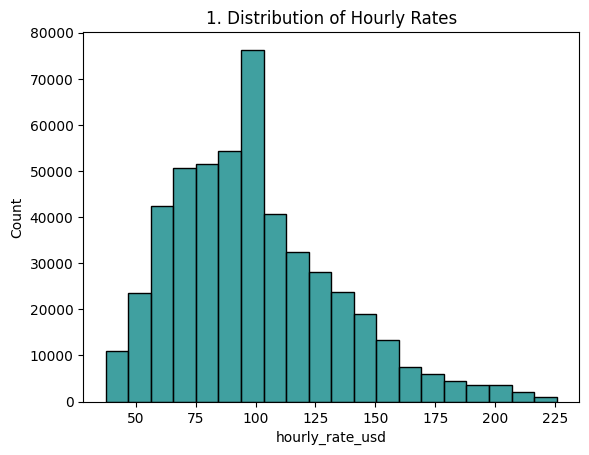

In [35]:
sns.histplot(df['hourly_rate_usd'] , bins = 20, color = 'teal')
plt.title("1. Distribution of Hourly Rates")
plt.show()

Count of Freelancers by Category (top10)

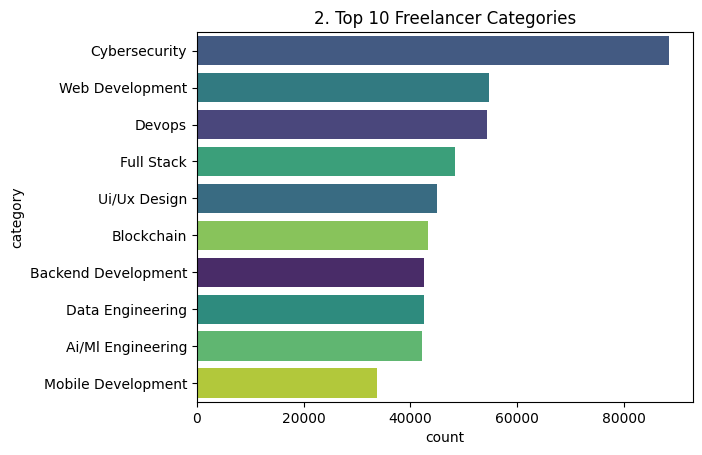

In [39]:
sns.countplot(data = df , y = 'category', order = df['category'].value_counts().index[:10], palette = 'viridis', hue = 'category', legend = False)
plt.title("2. Top 10 Freelancer Categories")
plt.show()

Avg Hourly Rate by Experience Level

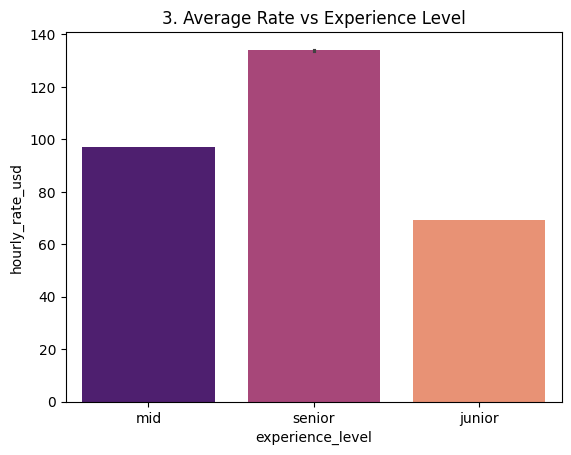

In [43]:
sns.barplot(data = df,x = 'experience_level', y = 'hourly_rate_usd' , palette = "magma", hue = 'experience_level', legend = False)
plt.title("3. Average Rate vs Experience Level")
plt.show()

Regional Distribution (Pie Chart)

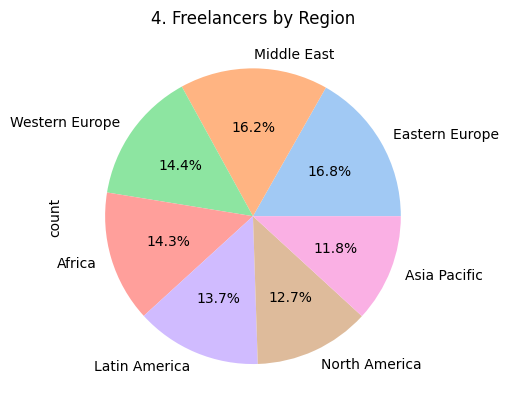

In [47]:
df['region'].value_counts().plot(kind = 'pie', autopct = '%1.1f%%' , colors = sns.color_palette('pastel'))
plt.title("4. Freelancers by Region")
plt.show()

Years of Experience vs Hourly Rate (Scatter Plot)

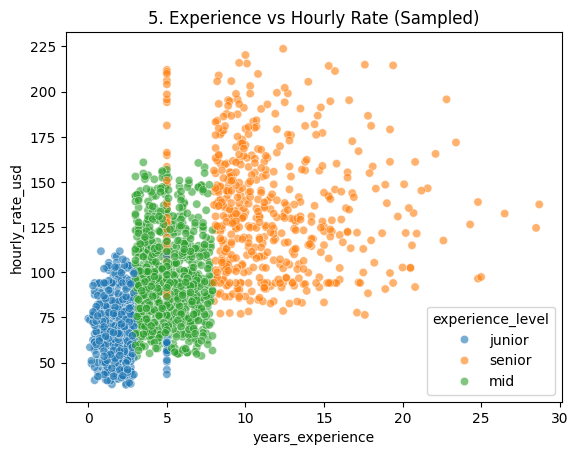

In [50]:
sns.scatterplot(data = df.sample(2000) , x= 'years_experience', y='hourly_rate_usd',hue = 'experience_level', alpha = 0.6)
plt.title("5. Experience vs Hourly Rate (Sampled)")
plt.show()

Education Level vs Annual Income (Box Plot)

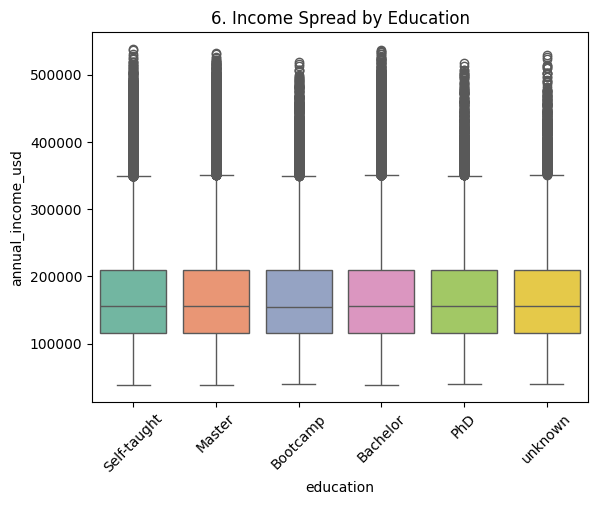

In [54]:
sns.boxplot(data = df, x = 'education', y= 'annual_income_usd' , palette = 'Set2', hue = 'education', legend = False)
plt.xticks(rotation=45)
plt.title("6. Income Spread by Education")
plt.show()

Primary Platform Usage

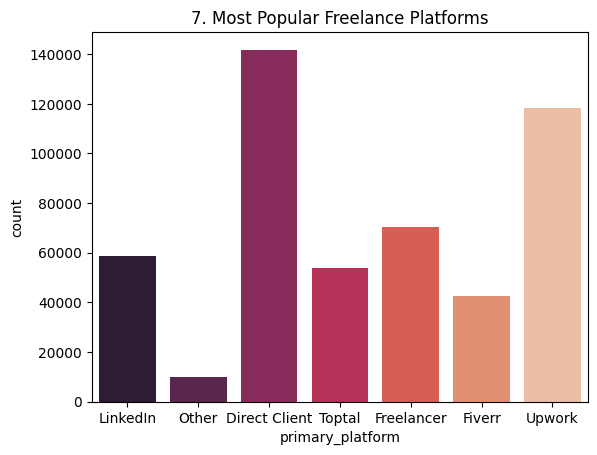

In [58]:
sns.countplot(data=df, x = 'primary_platform', palette = 'rocket', hue = 'primary_platform', legend = False)
plt.title("7. Most Popular Freelance Platforms")
plt.show()

Top 10 Countries by Avg Income

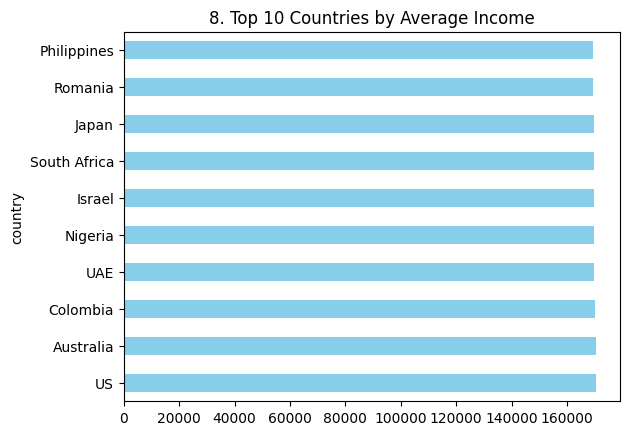

In [61]:
top_10 = df.groupby('country')['annual_income_usd'].mean().sort_values(ascending = False).head(10)
top_10.plot(kind = 'barh' , color = 'skyblue')
plt.title("8. Top 10 Countries by Average Income")
plt.show()

Correlation Heatmap

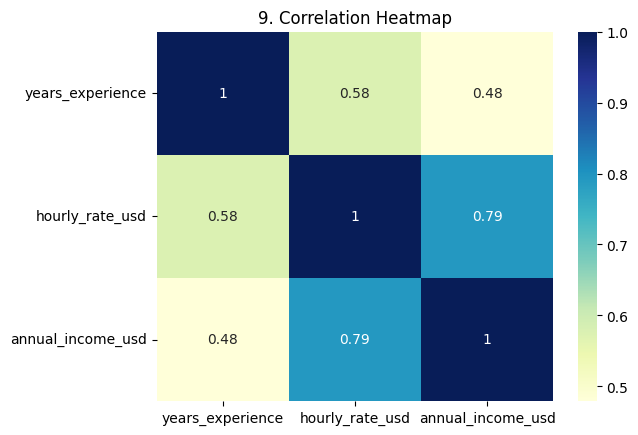

In [66]:
sns.heatmap(df[['years_experience','hourly_rate_usd', 'annual_income_usd']].corr() , annot = True , cmap = "YlGnBu")
plt.title("9. Correlation Heatmap")
plt.show()

In [62]:
df.columns

Index(['freelancer_id', 'category', 'region', 'education', 'primary_platform',
       'country', 'years_experience', 'experience_level', 'hourly_rate_usd',
       'annual_income_usd'],
      dtype='object')

Average Hourly Rate per Category

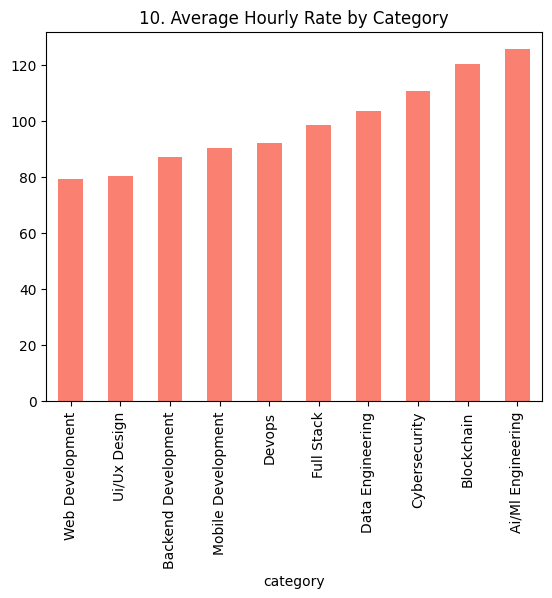

In [71]:
df.groupby('category')['hourly_rate_usd'].mean().sort_values().plot(kind='bar', color="salmon")
plt.title("10. Average Hourly Rate by Category")
plt.xticks(rotation=90)
plt.show()

Income Distribution by Experience Level (Violin Plot)

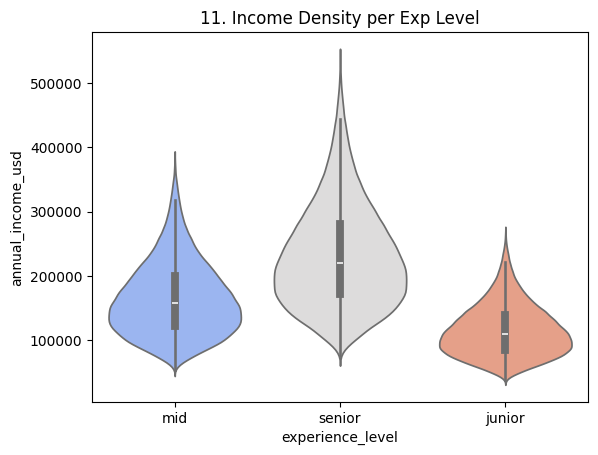

In [72]:
sns.violinplot(data=df, x='experience_level', y='annual_income_usd', palette="coolwarm", hue = 'experience_level', legend = False)
plt.title("11. Income Density per Exp Level")
plt.show()

Average Rate across Platforms (Line Plot)

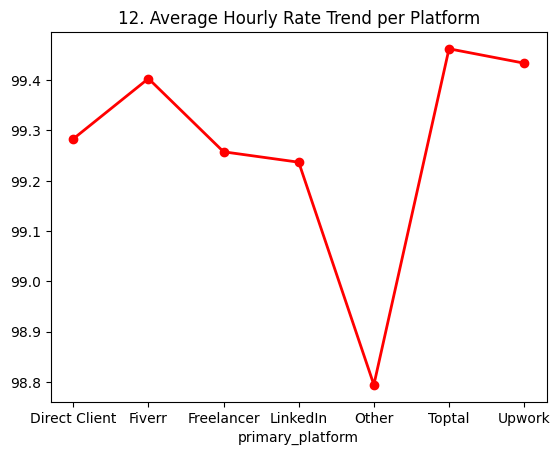

In [73]:
df.groupby('primary_platform')['hourly_rate_usd'].mean().plot(kind='line', marker='o', color='red', linewidth=2)
plt.title("12. Average Hourly Rate Trend per Platform")
plt.show()